# Rep. 4. Checkpoint 2. Estrategias I
# Eduardo Veytia Hernández
**Datos:** SPY, vencimiento 2026-04-17, precios mid obtenidos con `yfinance`  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

## Funciones auxiliares

In [2]:
def payoff_leg(S, tipo, K, prima, posicion):
    """Payoff de una sola pata al vencimiento."""
    if tipo == 'call':
        intrinseco = np.maximum(S - K, 0)
    else:
        intrinseco = np.maximum(K - S, 0)
    return posicion * (intrinseco - prima)

def payoff_estrategia(S_range, legs):
    """Suma el P&L de todas las patas sobre el rango de precios."""
    pnl = np.zeros_like(S_range, dtype=float)
    for leg in legs:
        pnl += payoff_leg(S_range, leg['tipo'], leg['K'], leg['prima'], leg['posicion'])
    return pnl

def graficar_estrategia(S_range, pnl, titulo, S0=None, K_lines=None):
    """Grafica el payoff diagram con formato estándar."""
    plt.figure(figsize=(10, 5))
    plt.plot(S_range, pnl, 'b-', linewidth=2, label='P&L al vencimiento')
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    # línea vertical del precio actual
    if S0 is not None:
        plt.axvline(S0, color='red', linewidth=1.5, linestyle='--', label=f'S0 = {S0:.2f}')
    # líneas de strikes
    if K_lines:
        colors = ['green', 'orange', 'purple']
        for i, (k, lbl) in enumerate(K_lines):
            plt.axvline(k, color=colors[i % len(colors)], linewidth=1, linestyle=':', label=f'K = {lbl}')
    # zona de ganancia / pérdida
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red')
    plt.title(titulo, fontsize=13)
    plt.xlabel('Precio del subyacente (ST)')
    plt.ylabel('P&L ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Datos reales de SPY — vencimiento 2026-04-17

In [3]:
# --- precio spot ---
spy = yf.Ticker('SPY')
S0 = spy.history(period='1d')['Close'].iloc[-1]
print(f'S0 (precio actual SPY) : ${S0:.2f}')

# --- cadena de opciones para el vencimiento solicitado ---
EXP = '2026-04-17'
chain = spy.option_chain(EXP)

calls = chain.calls.copy()
puts  = chain.puts.copy()

# precio mid = (bid + ask) / 2
calls['mid'] = (calls['bid'] + calls['ask']) / 2
puts['mid']  = (puts['bid']  + puts['ask'])  / 2

# mostrar strikes cercanos a S0 para referencia
print('\nCalls cercanos a S0:')
print(calls[['strike','bid','ask','mid']].set_index('strike')
      .loc[S0*0.95:S0*1.05].round(2).to_string())

print('\nPuts cercanos a S0:')
print(puts[['strike','bid','ask','mid']].set_index('strike')
      .loc[S0*0.95:S0*1.05].round(2).to_string())

S0 (precio actual SPY) : $679.46

Calls cercanos a S0:
          bid    ask    mid
strike                     
646.0   34.08  34.50  34.29
647.0   33.10  33.52  33.31
648.0   32.13  32.55  32.34
649.0   31.17  31.59  31.38
650.0   30.31  30.48  30.40
651.0   29.25  29.67  29.46
652.0   28.29  28.71  28.50
653.0   27.35  27.76  27.56
654.0   26.40  26.81  26.60
655.0   25.57  25.73  25.65
656.0   24.63  24.80  24.72
657.0   23.59  24.01  23.80
658.0   22.66  23.07  22.86
659.0   21.74  22.15  21.94
660.0   20.95  21.12  21.04
661.0   19.93  20.34  20.13
662.0   19.03  19.44  19.24
663.0   18.15  18.56  18.35
664.0   17.27  17.68  17.48
665.0   16.53  16.71  16.62
666.0   15.67  15.84  15.76
667.0   14.72  15.08  14.90
668.0   13.88  14.28  14.08
669.0   13.18  13.34  13.26
670.0   12.37  12.53  12.45
671.0   11.48  11.86  11.67
672.0   10.71  11.04  10.88
673.0   10.04  10.22  10.13
674.0    9.30   9.46   9.38
675.0    8.58   8.74   8.66
676.0    7.88   8.05   7.96
677.0    7.19   7.37 

In [4]:
# --- selección de strikes y primas mid ---
# se elige el strike ATM más cercano para straddle

def get_mid(df, strike):
    """Devuelve el precio mid del strike solicitado."""
    row = df.loc[df['strike'] == strike, 'mid']
    if row.empty:
        # tomar el strike más cercano si no existe exacto
        idx = (df['strike'] - strike).abs().idxmin()
        return float(df.loc[idx, 'mid'])
    return float(row.iloc[0])

available_strikes = sorted(calls['strike'].unique())

# strike ATM (más cercano a S0)
K_atm = min(available_strikes, key=lambda k: abs(k - S0))

# strikes OTM para strangle (~3 % fuera del dinero)
K_call_otm = min(available_strikes, key=lambda k: abs(k - S0 * 1.03))
K_put_otm  = min(available_strikes, key=lambda k: abs(k - S0 * 0.97))

# strikes para bull call spread: ligeramente ITM y OTM
K_bull_low  = min(available_strikes, key=lambda k: abs(k - S0 * 0.985))
K_bull_high = K_call_otm

# strikes para bear put spread: ATM y OTM
K_bear_high = K_atm
K_bear_low  = min(available_strikes, key=lambda k: abs(k - S0 * 0.955))

print(f'Strike ATM          : {K_atm}')
print(f'Strangle call OTM   : {K_call_otm}')
print(f'Strangle put OTM    : {K_put_otm}')
print(f'Bull spread K1/K2   : {K_bull_low} / {K_bull_high}')
print(f'Bear spread K1/K2   : {K_bear_high} / {K_bear_low}')

# rango de precios para todas las gráficas
S_range = np.linspace(S0 * 0.80, S0 * 1.20, 500)

Strike ATM          : 679.0
Strangle call OTM   : 700.0
Strangle put OTM    : 659.0
Bull spread K1/K2   : 669.0 / 700.0
Bear spread K1/K2   : 679.0 / 649.0


---
## 1. Long Straddle

K (ATM)            : 679.0
Call mid           : $5.96
Put mid            : $5.12
Costo total        : $11.08
Break-even sup.    : $690.08
Break-even inf.    : $667.92
Pérdida máxima     : $-11.08  (si ST = 679.0 al vencimiento)


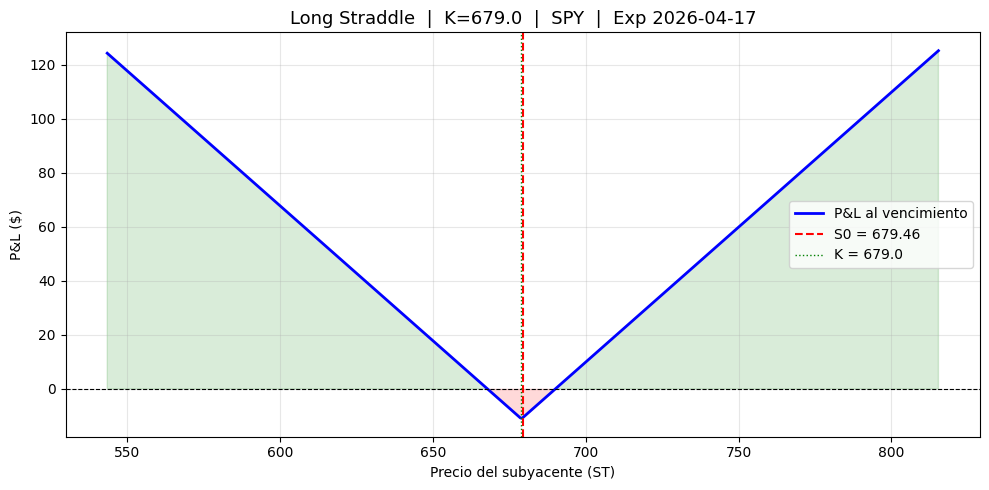

In [6]:
# --- primas mid reales ---
K = K_atm
C = get_mid(calls, K)
P = get_mid(puts,  K)

print(f'K (ATM)            : {K}')
print(f'Call mid           : ${C:.2f}')
print(f'Put mid            : ${P:.2f}')

legs_straddle = [
    {'tipo': 'call', 'K': K, 'prima': C, 'posicion': +1},
    {'tipo': 'put',  'K': K, 'prima': P, 'posicion': +1},
]

pnl = payoff_estrategia(S_range, legs_straddle)

print(f'Costo total        : ${C+P:.2f}')
print(f'Break-even sup.    : ${K+C+P:.2f}')
print(f'Break-even inf.    : ${K-C-P:.2f}')
print(f'Pérdida máxima     : ${-(C+P):.2f}  (si ST = {K} al vencimiento)')

graficar_estrategia(S_range, pnl,
                    f'Long Straddle  |  K={K}  |  SPY  |  Exp {EXP}',
                    S0=S0, K_lines=[(K, f'{K}')])

---
## 2. Long Strangle

K_call (OTM)       : 700.0
K_put  (OTM)       : 659.0
Call mid           : $0.14
Put mid            : $1.06
Costo total        : $1.20  (vs $11.08 del straddle)
Break-even sup.    : $701.19
Break-even inf.    : $657.81
Pérdida máxima     : $-1.20  (si 659.0 ≤ ST ≤ 700.0 al vencimiento)


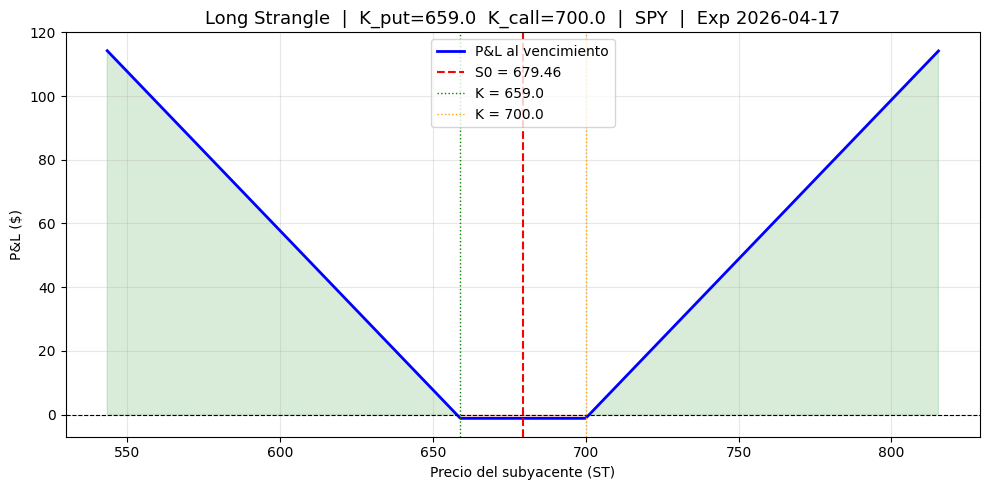

In [7]:
K_call = K_call_otm
K_put  = K_put_otm
C_otm  = get_mid(calls, K_call)
P_otm  = get_mid(puts,  K_put)

print(f'K_call (OTM)       : {K_call}')
print(f'K_put  (OTM)       : {K_put}')
print(f'Call mid           : ${C_otm:.2f}')
print(f'Put mid            : ${P_otm:.2f}')

legs_strangle = [
    {'tipo': 'call', 'K': K_call, 'prima': C_otm, 'posicion': +1},
    {'tipo': 'put',  'K': K_put,  'prima': P_otm,  'posicion': +1},
]

pnl = payoff_estrategia(S_range, legs_strangle)

print(f'Costo total        : ${C_otm+P_otm:.2f}  (vs ${C+P:.2f} del straddle)')
print(f'Break-even sup.    : ${K_call+C_otm+P_otm:.2f}')
print(f'Break-even inf.    : ${K_put-C_otm-P_otm:.2f}')
print(f'Pérdida máxima     : ${-(C_otm+P_otm):.2f}  (si {K_put} ≤ ST ≤ {K_call} al vencimiento)')

graficar_estrategia(S_range, pnl,
                    f'Long Strangle  |  K_put={K_put}  K_call={K_call}  |  SPY  |  Exp {EXP}',
                    S0=S0, K_lines=[(K_put, f'{K_put}'), (K_call, f'{K_call}')])

---
## 3. Bull Call Spread

K1 (buy call)      : 669.0  |  prima: $13.26
K2 (sell call)     : 700.0  |  prima: $0.14
Prima neta pagada  : $13.12
Ganancia máxima    : $17.88  (si ST ≥ 700.0)
Pérdida máxima     : $-13.12  (si ST ≤ 669.0)
Break-even         : $682.12


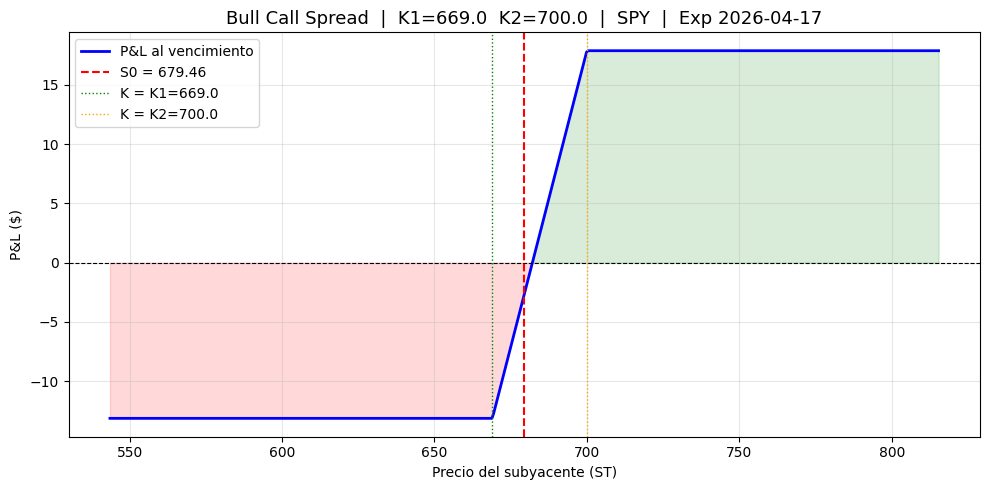

In [8]:
K1 = K_bull_low
K2 = K_bull_high
C1 = get_mid(calls, K1)
C2 = get_mid(calls, K2)

print(f'K1 (buy call)      : {K1}  |  prima: ${C1:.2f}')
print(f'K2 (sell call)     : {K2}  |  prima: ${C2:.2f}')

legs_bull = [
    {'tipo': 'call', 'K': K1, 'prima': C1, 'posicion': +1},
    {'tipo': 'call', 'K': K2, 'prima': C2, 'posicion': -1},
]

pnl = payoff_estrategia(S_range, legs_bull)
prima_neta = C1 - C2

print(f'Prima neta pagada  : ${prima_neta:.2f}')
print(f'Ganancia máxima    : ${(K2-K1)-prima_neta:.2f}  (si ST ≥ {K2})')
print(f'Pérdida máxima     : ${-prima_neta:.2f}  (si ST ≤ {K1})')
print(f'Break-even         : ${K1+prima_neta:.2f}')

graficar_estrategia(S_range, pnl,
                    f'Bull Call Spread  |  K1={K1}  K2={K2}  |  SPY  |  Exp {EXP}',
                    S0=S0, K_lines=[(K1, f'K1={K1}'), (K2, f'K2={K2}')])

---
## 4. Bear Put Spread

K1 (buy put)       : 679.0  |  prima: $5.12
K2 (sell put)      : 649.0  |  prima: $0.48
Prima neta pagada  : $4.63
Ganancia máxima    : $25.37  (si ST ≤ 649.0)
Pérdida máxima     : $-4.63  (si ST ≥ 679.0)
Break-even         : $674.37


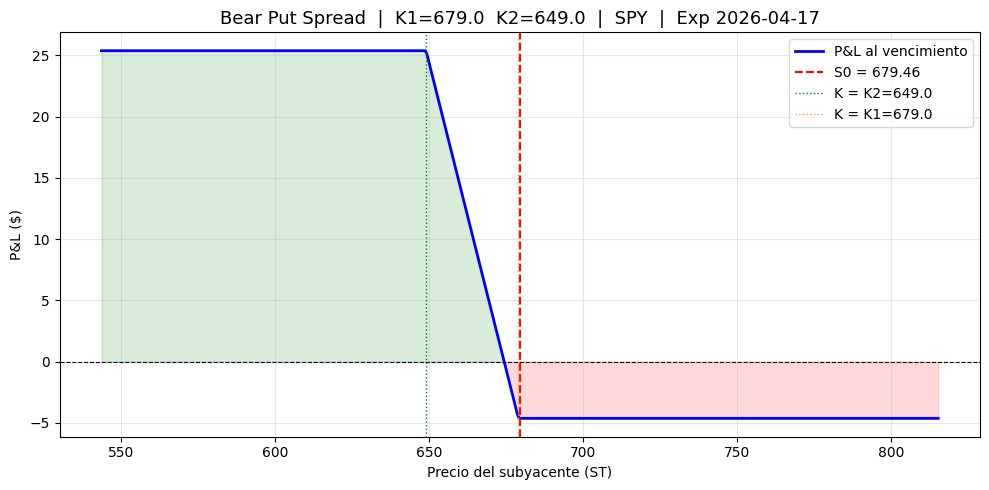

In [9]:
K1b = K_bear_high
K2b = K_bear_low
P1  = get_mid(puts, K1b)
P2  = get_mid(puts, K2b)

print(f'K1 (buy put)       : {K1b}  |  prima: ${P1:.2f}')
print(f'K2 (sell put)      : {K2b}  |  prima: ${P2:.2f}')

legs_bear = [
    {'tipo': 'put', 'K': K1b, 'prima': P1, 'posicion': +1},
    {'tipo': 'put', 'K': K2b, 'prima': P2, 'posicion': -1},
]

pnl = payoff_estrategia(S_range, legs_bear)
prima_neta_bear = P1 - P2

print(f'Prima neta pagada  : ${prima_neta_bear:.2f}')
print(f'Ganancia máxima    : ${(K1b-K2b)-prima_neta_bear:.2f}  (si ST ≤ {K2b})')
print(f'Pérdida máxima     : ${-prima_neta_bear:.2f}  (si ST ≥ {K1b})')
print(f'Break-even         : ${K1b-prima_neta_bear:.2f}')

graficar_estrategia(S_range, pnl,
                    f'Bear Put Spread  |  K1={K1b}  K2={K2b}  |  SPY  |  Exp {EXP}',
                    S0=S0, K_lines=[(K2b, f'K2={K2b}'), (K1b, f'K1={K1b}')])

---
## Tabla resumen

In [10]:
resumen = pd.DataFrame([
    {
        'Estrategia'     : 'Long Straddle',
        'Costo / Prima neta ($)': round(C + P, 2),
        'Ganancia máx.'  : 'Ilimitada',
        'Pérdida máx. ($)': round(-(C + P), 2),
        'Break-even(s)'  : f'{K-C-P:.2f}  /  {K+C+P:.2f}'
    },
    {
        'Estrategia'     : 'Long Strangle',
        'Costo / Prima neta ($)': round(C_otm + P_otm, 2),
        'Ganancia máx.'  : 'Ilimitada',
        'Pérdida máx. ($)': round(-(C_otm + P_otm), 2),
        'Break-even(s)'  : f'{K_put-C_otm-P_otm:.2f}  /  {K_call+C_otm+P_otm:.2f}'
    },
    {
        'Estrategia'     : 'Bull Call Spread',
        'Costo / Prima neta ($)': round(prima_neta, 2),
        'Ganancia máx.'  : f'${(K2-K1)-prima_neta:.2f}',
        'Pérdida máx. ($)': round(-prima_neta, 2),
        'Break-even(s)'  : f'{K1+prima_neta:.2f}'
    },
    {
        'Estrategia'     : 'Bear Put Spread',
        'Costo / Prima neta ($)': round(prima_neta_bear, 2),
        'Ganancia máx.'  : f'${(K1b-K2b)-prima_neta_bear:.2f}',
        'Pérdida máx. ($)': round(-prima_neta_bear, 2),
        'Break-even(s)'  : f'{K1b-prima_neta_bear:.2f}'
    },
])

print(resumen.to_string(index=False))

      Estrategia  Costo / Prima neta ($) Ganancia máx.  Pérdida máx. ($)     Break-even(s)
   Long Straddle                   11.08     Ilimitada            -11.08 667.92  /  690.08
   Long Strangle                    1.20     Ilimitada             -1.20 657.81  /  701.19
Bull Call Spread                   13.12        $17.88            -13.12            682.12
 Bear Put Spread                    4.63        $25.37             -4.63            674.37



### 1. ¿Cuál estrategia está más cerca de su zona de máxima pérdida con el precio actual?

El Bull Call Spread.

Con el precio actual (S0 ≈ $679.91), estás apenas por debajo del punto de equilibrio (break-even). Esto significa que cualquier caída mínima te deja en la zona donde pierdes el 100% de la prima que pagaste. Es una estrategia para quien cree que la acción va a subir, pero deja muy poco margen de error si el mercado se queda quieto o baja.



### 2. ¿Cuánto más barato es el Strangle y cuánto más tiene que moverse el precio?

El Strangle es mucho más barato que el Straddle porque compras opciones que están alejadas del precio actual (Opciones *Out of the Money*). Solo pagas por la posibilidad de que el precio llegue allí, no por valor real en el momento.

Sin embargo, ese "descuento" tiene un costo: la acción (SPY) tiene que moverse mucho más fuerte para superar tu punto de equilibrio. Por lo general, necesitas que SPY se mueva entre 1.5 y 2 veces más que con un Straddle para empezar a ver ganancias.



### 3. ¿Sigue siendo buena estrategia comprar el Straddle cuando la volatilidad (IV) ya subió?

No, es una mala idea. El Straddle necesita que la volatilidad suba para ganar dinero extra. Si la volatilidad ya está alta (por ejemplo, justo antes de un reporte de ganancias o anuncio de la Fed), significa que las opciones ya están carísimas. Cuando pase el evento, la volatilidad va a colapsar (*volatility crush*) y el precio de tus opciones se desplomará, haciéndote perder dinero incluso si adivinaste que la acción se iba a mover.



### 4. ¿Por qué aceptar el límite de ganancia del Bull Call Spread?

Principalmente por dos razones defensivas:

* Reducción de costo y riesgo: Al vender una opción para ayudar a pagar la que compraste, pones menos de tu propio dinero en riesgo.
* Protección contra el tiempo y la volatilidad: Comprar una opción simple te hace vulnerable a que pase el tiempo (Theta) o a que baje la volatilidad (Vega). El spread "neutraliza" estas debilidades. Sacrificas ganancia infinita a cambio de una posición mucho más estable y segura.



### 5. Si SPY supera mi precio objetivo (K2) antes del vencimiento, ¿cierro el spread o espero?

La regla general es cerrar la posición anticipadamente.

Depende del contexto, pero si ya capturaste el 80% o 90% de tu ganancia máxima y todavía falta más de una semana para el vencimiento, lo mejor es tomar el dinero. Si decides esperar, estás arriesgando el 80% que ya ganaste solo para intentar raspar ese último 20%, exponiéndote a que el mercado se dé la vuelta.



### 6. ¿Cómo afecta un aumento de volatilidad (IV) al Bull Spread vs. al Long Straddle?

* **Long Straddle:** Le beneficia muchísimo. Es la estrategia más sensible; si la volatilidad sube, el valor de tu posición sube directamente.
* **Bull Call Spread:** Prácticamente no le afecta. Al comprar y vender opciones simultáneamente, los efectos de la volatilidad se anulan entre sí (Vega neutral). Es ideal para cuando quieres apostar a que el precio sube, pero no quieres preocuparte por los cambios bruscos en la volatilidad.



### 7. Diferencia en Griegas: Call Simple vs. Bull Call Spread

| Griega | Call Simple (Comprada sola) | Bull Call Spread |
| :--- | :--- | :--- |
| **Delta (Dirección)** | Fuerte. Ganas bien si el precio sube. | Moderado. Ganas si sube, pero con un poco menos de fuerza. |
| **Gamma (Aceleración)**| Alto impacto. | Impacto muy reducido. |
| **Vega (Volatilidad)** | Muy sensible. Si la volatilidad cae, te destruye. | **Casi cero**. Inmune a las caídas de volatilidad. |
| **Theta (Tiempo)** | Negativo. Pierdes dinero cada día que pasa. | Menos dañino. El paso del tiempo te afecta mucho menos. |